In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import tensorflow as tf

from tensorflow.keras.layers import (
    Input,
    Embedding,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
    Concatenate,
)
from tensorflow.keras.models import Model
from sklearn.calibration import LabelEncoder

In [2]:
df = pd.read_parquet("../datasets/full_train_dataset_with_embeddings.parquet")

In [3]:
le = LabelEncoder()
df["Zipcode_endcoded"] = le.fit_transform(df["Zip-code"])
df = df.drop(columns=["Zip-code"])

In [4]:
df["original_langage_encoded"] = le.fit_transform(df["original_language"])
df = df.drop(columns=["original_language"])

In [5]:
df["occupation_encoded"] = le.fit_transform(df["Occupation"])
df = df.drop(columns=["Occupation"])

In [8]:
df = pd.get_dummies(
    df,
    columns=["Gender"],
    dtype=np.float32,
)

In [6]:
# feature columns
genre_cols = [
    "Action",
    "Adventure",
    "Animation",
    "Children's",
    "Comedy",
    "Crime",
    "Documentary",
    "Drama",
    "Fantasy",
    "Film-Noir",
    "Horror",
    "Musical",
    "Mystery",
    "Romance",
    "Sci-Fi",
    "Thriller",
    "War",
    "Western",
    "adult"
    
]
numeric_cols = ["popularity", "vote_average", "vote_count", "original_langage_encoded"]
user_cols = [
    "UserID",
    "Age",
    "occupation_encoded",
    "Zipcode_endcoded",
    "Gender_M",
    "Gender_F",
]

In [9]:
user_vecs = df[user_cols].to_numpy(dtype=np.float32)
item_vecs = df[genre_cols + numeric_cols].to_numpy(dtype=np.float32)
overview_embdeddings_vecs = np.stack(df["embedding"].values).astype(np.float32)
ratings = df["Rating"].to_numpy(dtype=np.float32)

In [10]:
u_train, u_test, e_train, e_test, i_train, i_test, y_train, y_test = train_test_split(
    user_vecs,
    overview_embdeddings_vecs,
    item_vecs,
    ratings,
    test_size=0.2,
    random_state=42,
)

In [27]:
n_users = df.UserID.max() + 1  # replace with: df.UserID.max()+1
user_dim = u_train.shape[1]

overview_dim = overview_embdeddings_vecs.shape[1]  # embedding dimension
n_genres = len(genre_cols)  
n_numeric = len(numeric_cols)
movie_dim = n_genres + n_numeric

# ——— Inputs ———
inp_user = Input(shape=(user_dim,), name="user_id")
inp_movie = Input(shape=(movie_dim,), name="movie_feat")
inp_overview = Input(shape=(overview_dim,), name="overview_emb_feat")
# ——— User tower ———
u = Embedding(input_dim=n_users, output_dim=user_dim, name="user_emb")(inp_user)
u = Flatten()(u)
u = Dense(64, activation="relu")(u)
u = Dropout(0.2)(u)

# ——— Movie tower ———
m = Dense(256, activation="relu")(inp_movie)
m = BatchNormalization()(m)
m = Dropout(0.3)(m)
m = Dense(128, activation="relu")(m)
m = Dropout(0.2)(m)

# ——— Overview tower ———
e = Dense(256, activation="relu")(inp_overview)
e = BatchNormalization()(e)
e = Dropout(0.3)(e)
e = Dense(128, activation="relu")(e)
e = Dropout(0.2)(e)

# ——— Combine & head ———
x = Concatenate()([u, m, e])
x = Dense(512, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Dense(256, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Dense(64, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Dense(32, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

out = Dense(1, name="rating")(x)  # linear activation for regression

In [28]:
model = Model([inp_user, inp_movie, inp_overview], out)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="mse",
    metrics=[tf.keras.metrics.RootMeanSquaredError()],
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ movie_feat          │ (None, 23)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ overview_emb_feat   │ (None, 384)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_id             │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 256)       │      6,144 │ movie_feat[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 256)       │     98,560 │ overview_emb_fea… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_emb            │ (None, 6, 6)      │     36,246 │ user_id[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_28[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_30[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 36)        │          0 │ user_emb[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_28          │ (None, 256)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_30          │ (None, 256)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 64)        │      2,368 │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 128)       │     32,896 │ dropout_28[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 128)       │     32,896 │ dropout_30[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_27          │ (None, 64)        │          0 │ dense_27[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_29          │ (None, 128)       │          0 │ dense_29[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_31          │ (None, 128)       │          0 │ dense_31[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 320)       │          0 │ dropout_27[0][0], │
│ (Concatenate)       │                   │            │ dropout_29[0][0], │
│                     │                   │            │ dropout_31[0][0]  │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 528,855 (2.02 MB)

 Trainable params: 526,103 (2.01 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [29]:
history = model.fit(
    x=[u_train, i_train, e_train],
    y=y_train,
    batch_size=256,
    epochs=15,
    validation_split=0.2,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_root_mean_squared_error", patience=5, restore_best_weights=True
        )
    ],
)

Epoch 1/15
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step - loss: 4.2560 - root_mean_squared_error: 1.9770 - val_loss: 0.9336 - val_root_mean_squared_error: 0.9662
Epoch 2/15
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 1.0171 - root_mean_squared_error: 1.0085 - val_loss: 0.8772 - val_root_mean_squared_error: 0.9366
Epoch 3/15
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 0.9430 - root_mean_squared_error: 0.9711 - val_loss: 0.8524 - val_root_mean_squared_error: 0.9232
Epoch 4/15
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 0.8967 - root_mean_squared_error: 0.9470 - val_loss: 0.8300 - val_root_mean_squared_error: 0.9110
Epoch 5/15
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 29s 12ms/step - loss: 0.8640 - root_mean_squared_error: 0.9295 - val_loss: 0.8227 - val_root_mean_squared_error: 0.9070
Epoch 6/15
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 29s 12ms/step - loss: 0.8433 - root_mean_squared_error: 0.9183 - val_loss: 0.8172 - val_root_mean_squared_error: 0.9040
Epoch 7/15
2501/2501 ━━━━━━━

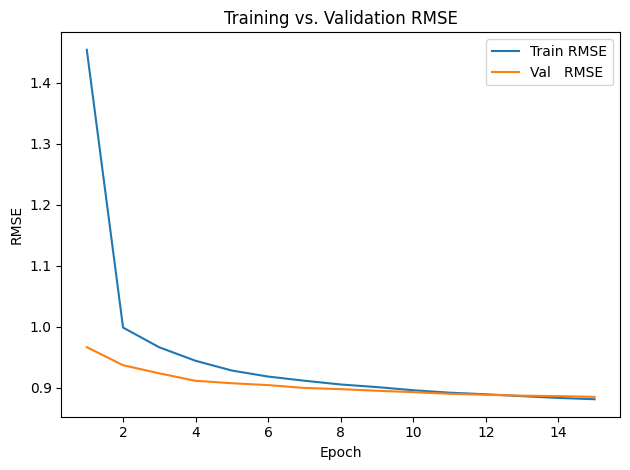

In [31]:
import matplotlib.pyplot as plt


train_rmse = history.history["root_mean_squared_error"]
val_rmse = history.history["val_root_mean_squared_error"]
epochs = range(1, len(train_rmse) + 1)

plt.figure()
plt.plot(epochs, train_rmse, label="Train RMSE")
plt.plot(epochs, val_rmse, label="Val   RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Training vs. Validation RMSE")
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
train_rmse = history.history["root_mean_squared_error"]
val_rmse = history.history["val_root_mean_squared_error"]
print(f"Final Train RMSE: {train_rmse[-1]:.4f}")
print(f"Final Validation RMSE: {val_rmse[-1]:.4f}")

Final Train RMSE: 0.8808
Final Validation RMSE: 0.8847


In [34]:
model.save("../models/mlp_with_overview/1/model.keras", )

In [35]:
model_json = model.to_json()
with open("../models/mlp_with_overview/1/model_architecture.json", "w") as f:
    f.write(model_json)

In [36]:
model.save_weights("../models/mlp_with_overview/1/model.weights.h5")